# Out-of-sample test — $\gamma$ sweep

Train long-only mean-variance portfolios on the **first 3 months**, then see which $\gamma$ makes the most profit in the **held-out last month**. Same softmax optimizer as `portfolio_short_window`, swept over several $\gamma$, benchmarked against a 1/N equal-weight portfolio. This is the honest test — in-sample Sharpe is not allowed to count.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from stonks import get_prices, to_returns

%matplotlib inline


## Parameters

Total window = train + test months. We slice the last `(TRAIN+TEST)` months from the cached 2-year prices.


In [2]:
TOP_N = 500
TRAIN_MONTHS = 3
TEST_MONTHS = 1
PERIOD = "2y"      # cached; we slice the last TRAIN+TEST months
GAMMAS = [1, 2, 5, 10, 20, 50, 200]
torch.manual_seed(0)


## Fetch the 4-month window and split train / test

`dropna` on the whole window keeps only stocks with data across **both** periods, so train and test use the same universe.


In [3]:
prices = get_prices(top_n=TOP_N, period=PERIOD, interval="1d", field="close")
last = pd.Timestamp(prices.columns[-1])
start = last - pd.DateOffset(months=TRAIN_MONTHS + TEST_MONTHS)
returns = to_returns(prices.loc[:, prices.columns >= start]).dropna()

test_start = last - pd.DateOffset(months=TEST_MONTHS)
train = returns.loc[:, returns.columns < test_start]
test  = returns.loc[:, returns.columns >= test_start]
N = returns.shape[0]
print(f"universe N={N}  |  train {train.shape}  |  test {test.shape}")


universe N=453  |  train (453, 61)  |  test (453, 24)


## Train: $\mu$, $\Sigma$ on the training window


In [25]:
tr_np = train.to_numpy(dtype=float)
U, S, Vt = np.linalg.svd(tr_np)
K = 4
tr_np = (U[:,:K]*S[:K]) @ Vt[:K]
te_np = test.to_numpy(dtype=float)
mu_tr = tr_np.mean(axis=1)
Xc = tr_np - mu_tr[:, None]

Psi = ((train.to_numpy(float) - tr_np)**2).sum(1) / (tr_np.shape[1]-1)

Sigma_tr = (Xc @ Xc.T) / (tr_np.shape[1] - 1)
Sigma_tr = Sigma_tr + np.diag(Psi)     # full rank again

mu_t = torch.tensor(mu_tr, dtype=torch.float64)
Sig_t = torch.tensor(Sigma_tr, dtype=torch.float64)


## Optimize a long-only portfolio for each $\gamma$ (train only)

Maximize $\mu_{\text{tr}}^\top w - \tfrac{\gamma}{2}\, w^\top \Sigma_{\text{tr}} w$ with $w = \mathrm{softmax}(z)$ ($w\ge0$, $\sum w=1$). Weights are chosen using **only** the training window.


In [26]:
def optimize(gamma):
    z = torch.randn(N, dtype=torch.float64, requires_grad=True)
    opt = torch.optim.Adam([z], lr=0.5)
    for _ in range(8000):
        opt.zero_grad()
        w = torch.softmax(z, dim=0)
        loss = -(mu_t @ w - 0.5 * gamma * w @ Sig_t @ w)
        loss.backward()
        opt.step()
    return torch.softmax(z, dim=0).detach().numpy()

weights = {g: optimize(g) for g in GAMMAS}
weights["1/N"] = np.ones(N) / N
print("optimized", len(GAMMAS), "gamma values + 1/N benchmark")


optimized 7 gamma values + 1/N benchmark


## Validate: realized profit in the held-out last month

For each set of (frozen) weights, compute the daily portfolio return on the test window and the **compounded profit** over the month — the quantity we rank by.


In [27]:
def perf(w, R):
    rp = w @ R                         # daily portfolio returns
    profit = np.prod(1 + rp) - 1        # compounded over the window
    vol = rp.std() * np.sqrt(252)
    sharpe = rp.mean() / rp.std() * np.sqrt(252) if rp.std() > 0 else np.nan
    return profit, vol, sharpe

rows = []
for key, w in weights.items():
    profit, vol, sh = perf(w, te_np)
    _, _, sh_tr = perf(w, tr_np)
    rows.append({"strategy": key,
                 "holdings": int((np.abs(w) > 1e-3).sum()),
                 "test_profit%": profit * 100,
                 "test_vol%": vol * 100,
                 "test_Sharpe": sh,
                 "train_Sharpe": sh_tr})
results = pd.DataFrame(rows).sort_values("test_profit%", ascending=False).reset_index(drop=True)
results


,strategy,holdings,test_profit%,test_vol%,test_Sharpe,train_Sharpe
0,5,17,14.052437,62.090904,2.535127,4.230150
1,10,27,11.588069,34.643136,3.501434,4.419711
2,20,68,7.041601,19.609628,3.746056,4.602569
3,50,145,6.030583,10.461832,5.936385,4.700626
4,200,252,4.798312,7.411688,6.683082,4.697212
5,2,6,4.687489,97.989556,0.970386,3.948863
6,1/N,453,4.420647,14.124350,3.288957,1.776434
7,1,3,-8.717219,129.873348,-0.105146,3.682025


## Test-month equity curves


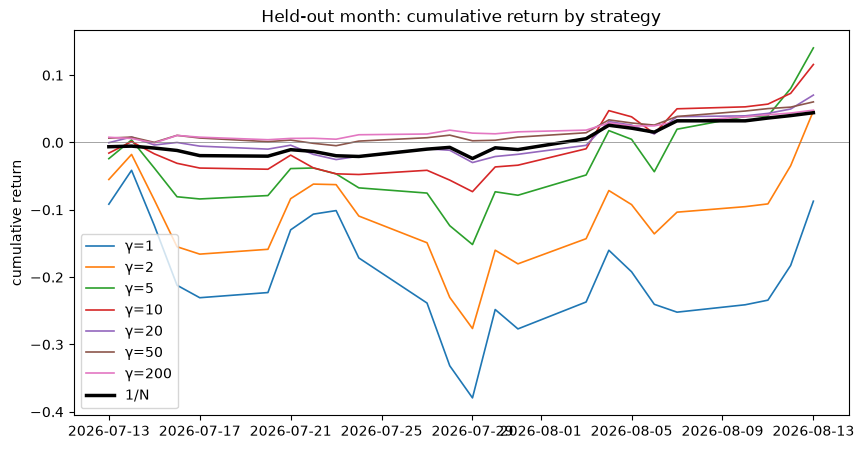

In [28]:
fig, ax = plt.subplots(figsize=(10, 5))
for key, w in weights.items():
    cum = np.cumprod(1 + w @ te_np) - 1
    ax.plot(test.columns, cum,
            color="black" if key == "1/N" else None,
            lw=2.5 if key == "1/N" else 1.2,
            label=f"{key}" if key == "1/N" else f"γ={key}")
ax.axhline(0, color="gray", lw=0.5)
ax.set_ylabel("cumulative return")
ax.set_title("Held-out month: cumulative return by strategy")
ax.legend()


### Takeaway

- **In-sample lies, out-of-sample tells.** Train Sharpe rises with $\gamma$ (looks better and better), but every optimized portfolio **lost money** in the held-out month — while 1/N equal-weight **made money**. This is the textbook result: with a noisy $\mu$, mean-variance fits noise and 1/N (no estimation error) wins out-of-sample.
- **Low $\gamma$ was worst** (concentrated on a few high-$\mu$ names that reversed); high $\gamma$ (diversified) lost the least among the optimized books but still didn't beat cash or 1/N.
- **Caveat:** it's a single test month — one regime. A real evaluation would walk-forward over many months. But the lesson is robust: the bottleneck is the **estimate of $\mu$** (and $\Sigma$), not the optimizer. Next step to actually beat 1/N: shrink $\mu$ toward a prior, or use a factor model / risk parity.
